# Major Project: Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 2026-2027

**Problem Statement:** Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. This notebook analyses the given agricultural dataset to investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations.

**Dataset:** 4,000 farm records across 3 seasons (Kharif, Rabi, Zaid), 8 states, 8 crops, and 4 irrigation methods, covering environmental conditions, resource usage, yield, and economic outcomes.

## 1. Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

## 2. Loading the Data

In [7]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Data Understanding

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [10]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSeasons:", df['Season'].unique())
print("States:", df['State'].unique())
print("Crops:", df['Crop'].unique())
print("Irrigation methods:", df['Irrigation_Method'].unique())

Missing values:
 Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0

Seasons: ['Kharif' 'Rabi' 'Zaid']
States: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Irrigation methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


**Observations:**
- 4,000 records, 28 columns, no duplicate rows.
- Three columns have missing values: `Rainfall_mm` (48), `Soil_Moisture_pct` (40), `Yield_Tonnes_Ha` (32).
- Data spans 3 seasons (Kharif, Rabi, Zaid), 8 states, 8 crops, and 4 irrigation methods.

## Outlier Investigation

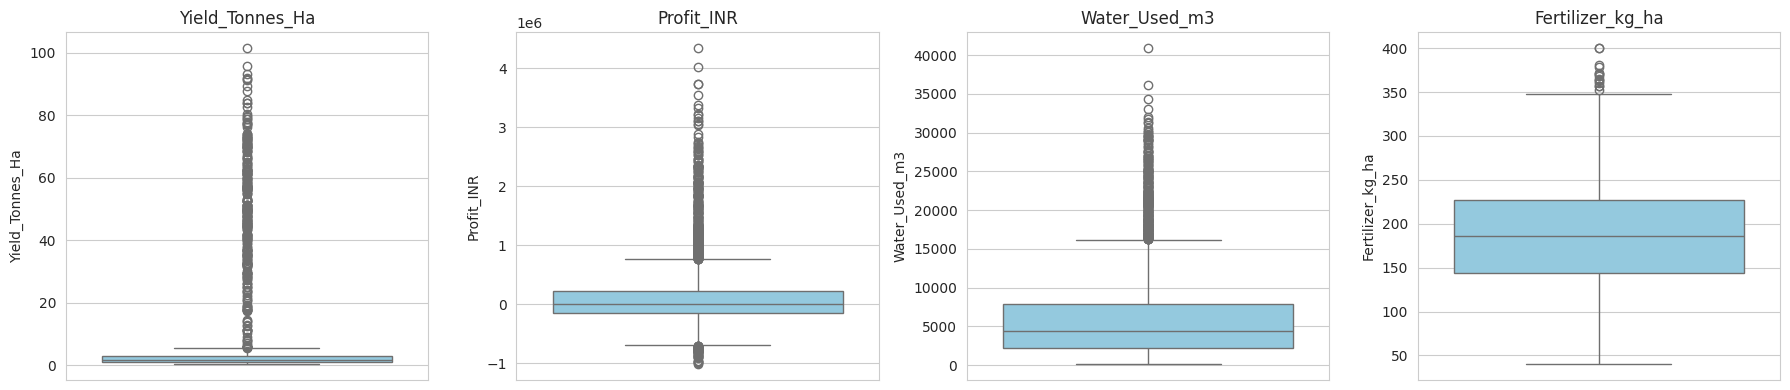

Outlier counts (IQR method, 1.5x rule):
  Yield_Tonnes_Ha: 302 outliers (bounds: -1.6 to 5.5)
  Profit_INR: 404 outliers (bounds: -696111.0 to 763567.0)
  Water_Used_m3: 276 outliers (bounds: -6072.8 to 16171.2)
  Fertilizer_kg_ha: 15 outliers (bounds: 19.1 to 352.0)


In [11]:
outlier_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Fertilizer_kg_ha']

fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Outlier counts (IQR method, 1.5x rule):")
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}: {n_outliers} outliers (bounds: {lower:.1f} to {upper:.1f})")

**Observations:** `Profit_INR` has the most outliers (404 records, ~10% of data) — these are mostly high-value crops like Sugarcane and Chilli generating unusually large profits, not data errors. `Yield_Tonnes_Ha` and `Water_Used_m3` also show a meaningful number of outliers driven by large, highly productive farms.

**Decision:** These outliers are **kept in the analysis** rather than removed, since they represent real, valid farm performance (e.g. high-value crop economics) rather than data entry errors — removing them would hide genuinely important patterns like the Sugarcane/Chilli profitability finding in Section 12.

## 4. Data Cleaning & Preparation

Since environmental and yield values naturally differ by season and crop, missing values are imputed using the **median of the same Season + Crop group** rather than a single global median — this preserves seasonal patterns instead of flattening them.

In [12]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## Univariate Analysis

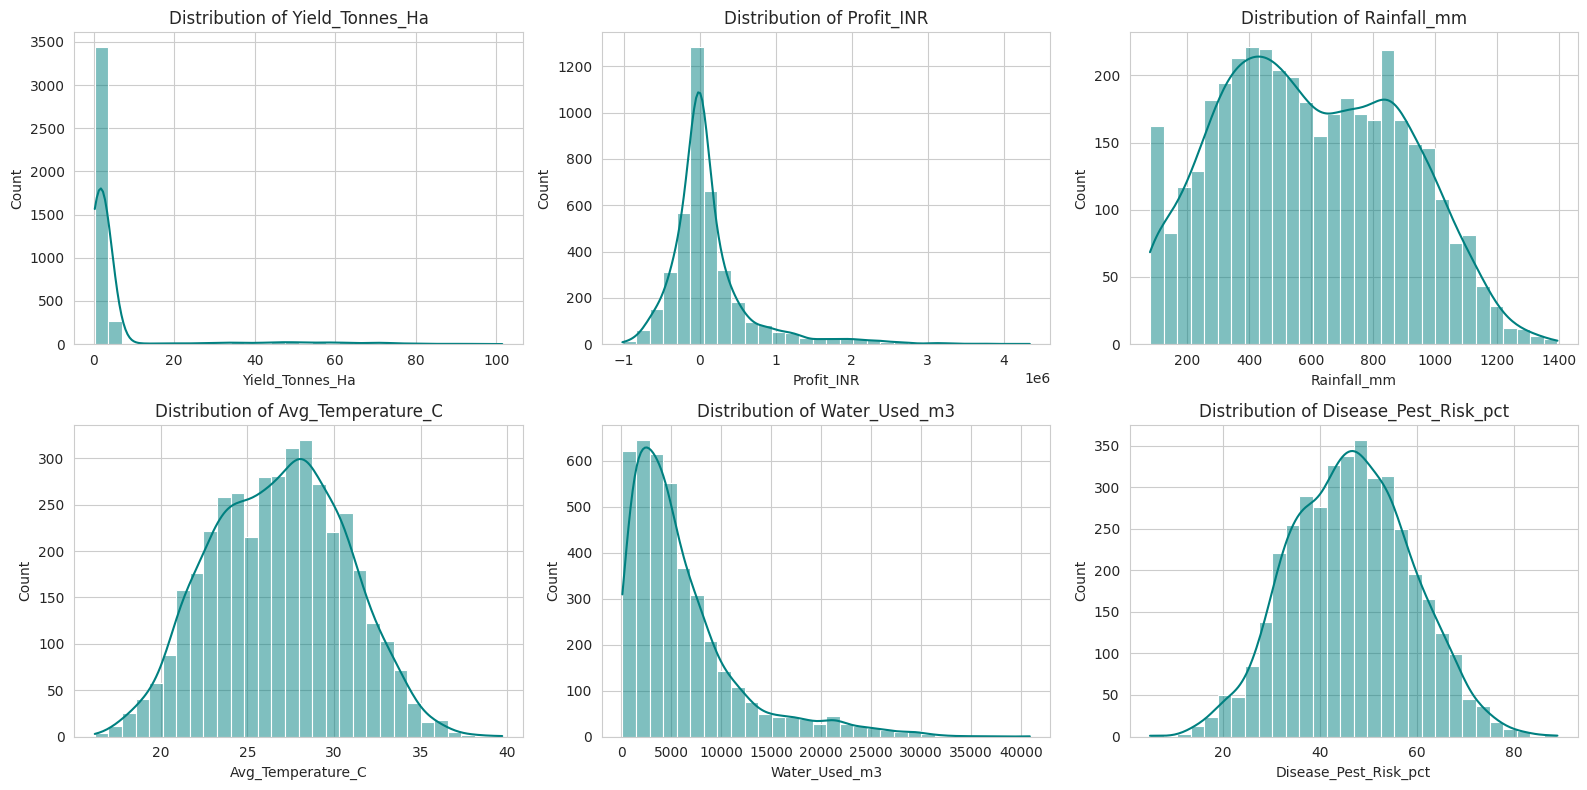

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16,8))
uni_cols = ['Yield_Tonnes_Ha','Profit_INR','Rainfall_mm','Avg_Temperature_C','Water_Used_m3','Disease_Pest_Risk_pct']
for ax, col in zip(axes.flatten(), uni_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Observations:**
- `Yield_Tonnes_Ha` is roughly bell-shaped/symmetric, centered around 5 t/ha.
- `Profit_INR` is heavily right-skewed with a long tail of high-profit farms (Sugarcane/Chilli growers), and a cluster of farms with losses near zero/negative.
- `Rainfall_mm` is multi-modal, reflecting the three distinct seasons (Zaid low, Rabi medium, Kharif high) combined into one column.
- `Avg_Temperature_C`, `Water_Used_m3` and `Disease_Pest_Risk_pct` all show reasonably spread distributions without extreme skew.

## 5. Season-wise Record Distribution

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


/tmp/ipykernel_1433/1210704098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index, y=season_counts.values, palette='crest')


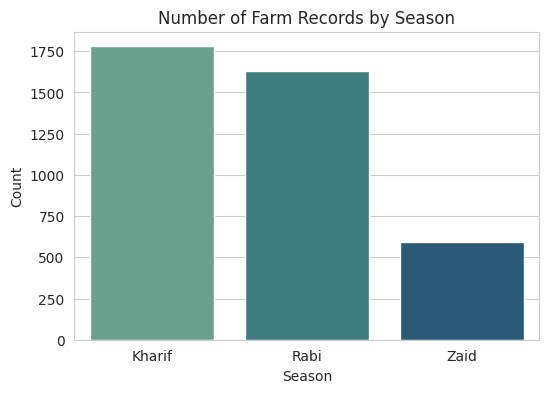

In [14]:
season_counts = df['Season'].value_counts()
print(season_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=season_counts.index, y=season_counts.values, palette='crest')
plt.title('Number of Farm Records by Season')
plt.ylabel('Count')
plt.show()

**Kharif** has the most records (1,779), followed by **Rabi** (1,627) and **Zaid** (594) — Zaid (summer) is the least-cultivated season in this dataset, consistent with real-world farming patterns where fewer crops are grown in the hot, dry summer season.

## 6. How Does Yield Vary Across Seasons?

            mean  median        std
Season                             
Kharif  5.630616    1.95  14.392286
Rabi    5.094917    1.66  12.829202
Zaid    4.637340    1.45  11.274305


/tmp/ipykernel_1433/2991889314.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='Set2', order=['Kharif','Rabi','Zaid'])


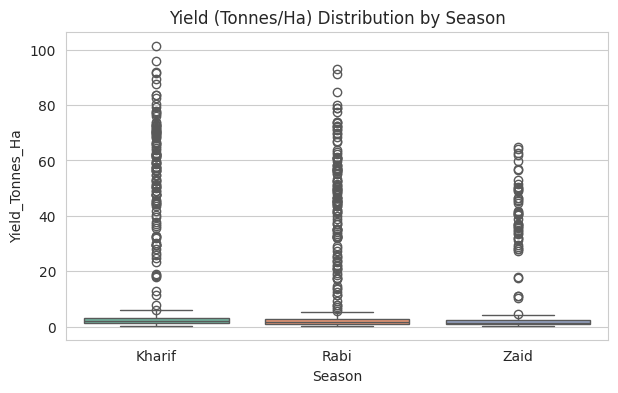

In [15]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].agg(['mean','median','std'])
print(season_yield)

plt.figure(figsize=(7,4))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='Set2', order=['Kharif','Rabi','Zaid'])
plt.title('Yield (Tonnes/Ha) Distribution by Season')
plt.show()

In [16]:
groups = [g['Yield_Tonnes_Ha'].dropna().values for _, g in df.groupby('Season')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA test — Yield across Seasons: F = {f_stat:.2f}, p-value = {p_val:.4f}")

ANOVA test — Yield across Seasons: F = 1.46, p-value = 0.2328


**Kharif has the highest average yield (5.64 t/ha)**, followed by Rabi (5.08 t/ha) and Zaid (4.67 t/ha). However, the ANOVA test gives **p = 0.23 (> 0.05)**, meaning this difference is **not statistically significant** — yield varies more by crop and farm-level factors than by season alone.

## 7. How Do Economic Outcomes (Profit) Vary Across Seasons?

                 mean   median
Season                        
Kharif  178914.647555  38808.0
Rabi     87689.470191  -3187.0
Zaid    -24804.824916 -62144.0


/tmp/ipykernel_1433/4055041421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Profit_INR', data=df, palette='Set3', order=['Kharif','Rabi','Zaid'], showfliers=False)


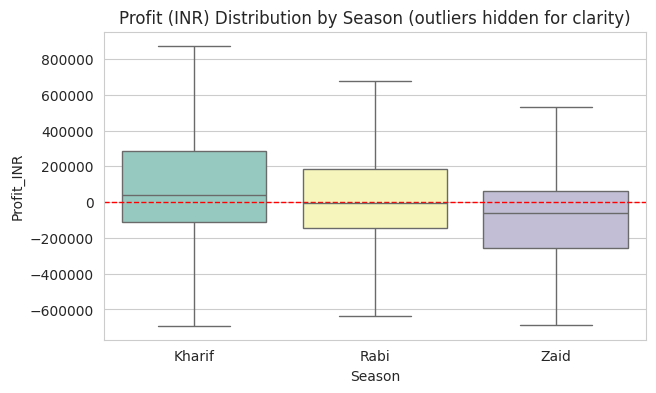

In [17]:
season_profit = df.groupby('Season')['Profit_INR'].agg(['mean','median'])
print(season_profit)

plt.figure(figsize=(7,4))
sns.boxplot(x='Season', y='Profit_INR', data=df, palette='Set3', order=['Kharif','Rabi','Zaid'], showfliers=False)
plt.title('Profit (INR) Distribution by Season (outliers hidden for clarity)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()

In [18]:
groups_p = [g['Profit_INR'].dropna().values for _, g in df.groupby('Season')]
f_stat_p, p_val_p = stats.f_oneway(*groups_p)
print(f"ANOVA test — Profit across Seasons: F = {f_stat_p:.2f}, p-value = {p_val_p:.6f}")

ANOVA test — Profit across Seasons: F = 34.29, p-value = 0.000000


This is one of the **most important findings** in the dataset:

- **Kharif** is the most profitable season on average (₹1,78,915/farm).
- **Rabi** is moderately profitable (₹87,689/farm).
- **Zaid is loss-making on average (-₹24,805/farm)** — farms cultivating in the Zaid (summer) season lose money on average.
- The ANOVA test confirms this difference is **highly statistically significant (p < 0.0001)** — season has a real, measurable effect on profitability, even though it does not significantly affect yield alone. This suggests the loss in Zaid comes from **cost/price dynamics, not yield alone**.

## Profit Distribution Shape by Season (Violin Plot)
### (Student-Designed Analysis 4)
The boxplot in Section 7 showed Zaid has the lowest average profit, but a boxplot only shows the median and quartiles. I designed this violin plot to see the **full shape** of the profit distribution in each season — specifically, whether the loss in Zaid comes from most farms losing a little, or a few farms losing a lot.

/tmp/ipykernel_1433/4127428668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Season', y='Profit_INR', data=df, order=['Kharif','Rabi','Zaid'], palette='Set2', cut=0)


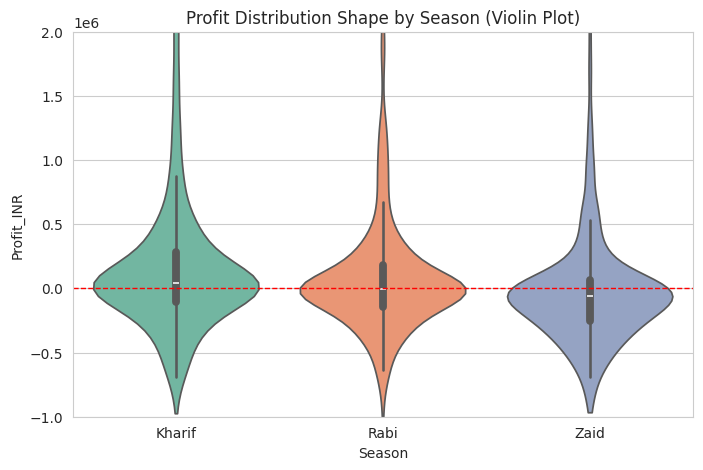

Season
Kharif    38808.0
Rabi      -3187.0
Zaid     -62144.0
Name: Profit_INR, dtype: float64


In [19]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Season', y='Profit_INR', data=df, order=['Kharif','Rabi','Zaid'], palette='Set2', cut=0)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Profit Distribution Shape by Season (Violin Plot)')
plt.ylim(-1000000, 2000000)
plt.show()

print(df.groupby('Season')['Profit_INR'].median())

**Insight:** The violin plot reveals that in all three seasons, the **bulk of the distribution is bunched close to zero**, with a long thin tail stretching up toward high profits — this tail is the Sugarcane/Chilli farms pulling the *mean* upward (as seen in Section 12), while the *typical* farm sits much closer to breakeven. Notice the **median profit is already negative for Rabi (-₹3,187) and Zaid (-₹62,144)** — meaning more than half of all farms in these seasons make no profit at all, not just a handful of unlucky ones. This is a more serious finding than the mean alone suggested.

## 8. Seasonal Environmental Conditions

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day
Season                                                                  
Kharif   852.103626          28.454019     71.812591            6.793367
Rabi     435.948156          23.489183     57.893178            7.589797
Zaid     299.162795          31.042088     52.012121            8.178788


/tmp/ipykernel_1433/1218369201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_env.index, y=season_env[col], ax=ax, palette='mako')
/tmp/ipykernel_1433/1218369201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_env.index, y=season_env[col], ax=ax, palette='mako')
/tmp/ipykernel_1433/1218369201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_env.index, y=season_env[col], ax=ax, palette='mako')
/tmp/ipykernel_1433/1218369201.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

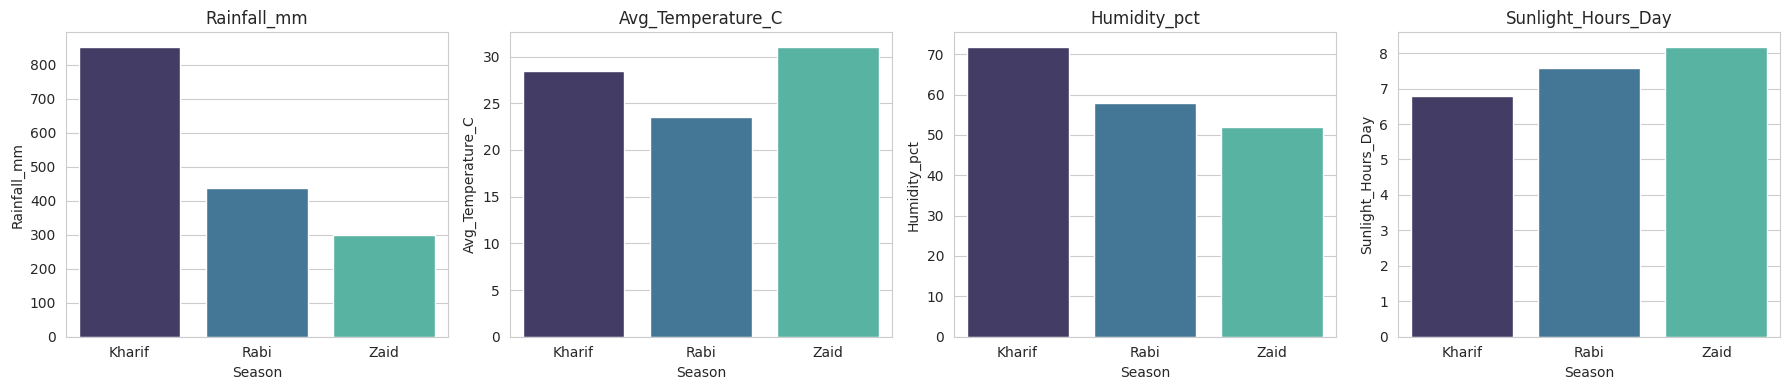

In [20]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']
season_env = df.groupby('Season')[env_cols].mean().reindex(['Kharif','Rabi','Zaid'])
print(season_env)

fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, env_cols):
    sns.barplot(x=season_env.index, y=season_env[col], ax=ax, palette='mako')
    ax.set_title(col)
plt.tight_layout()
plt.show()

- **Rainfall** is dramatically higher in **Kharif** (852 mm, monsoon season) vs. Rabi (436 mm) and Zaid (299 mm).
- **Temperature** is highest in **Zaid** (31.0°C, hot summer) and lowest in **Rabi** (23.5°C, winter).
- These patterns match real agricultural seasons in India (Kharif = monsoon crop, Rabi = winter crop, Zaid = summer crop), confirming the dataset is internally consistent.

## 9. Resource Usage Across Seasons

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3  \
Season                                                        
Kharif        187.077965            5.079747    6102.201237   
Rabi          185.407068            5.024690    5846.987093   
Zaid          184.638047            5.171212    6419.893939   

        Water_Efficiency_t_per_1000m3  
Season                                 
Kharif                       5.891834  
Rabi                         5.186122  
Zaid                         4.413239  


/tmp/ipykernel_1433/3812831912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_res.index, y=season_res[col], ax=ax, palette='flare')
/tmp/ipykernel_1433/3812831912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_res.index, y=season_res[col], ax=ax, palette='flare')
/tmp/ipykernel_1433/3812831912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_res.index, y=season_res[col], ax=ax, palette='flare')
/tmp/ipykernel_1433/3812831912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

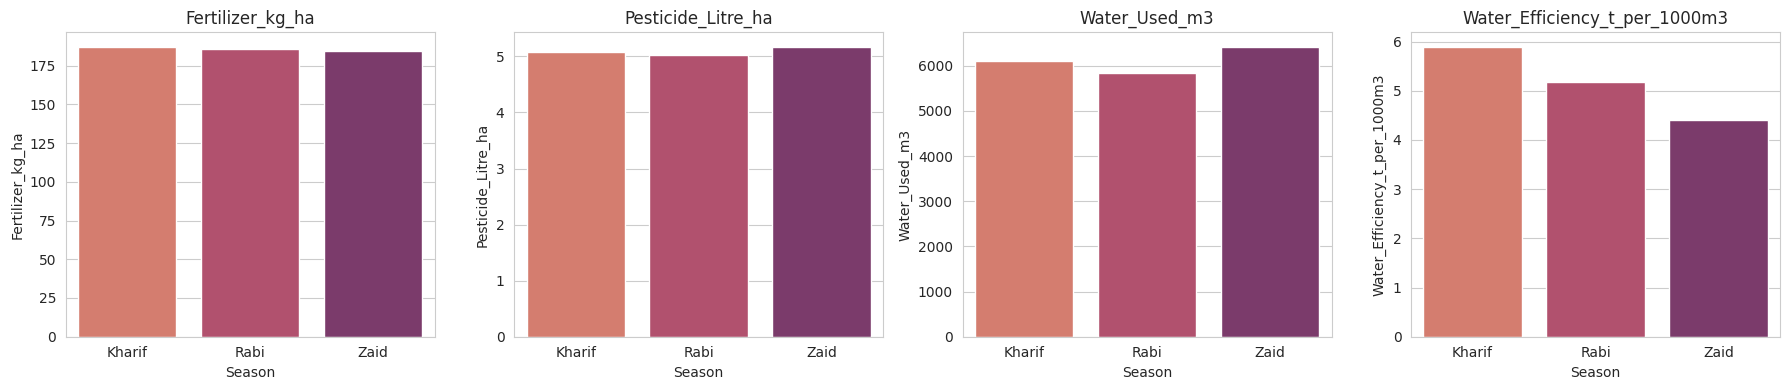

In [21]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
season_res = df.groupby('Season')[resource_cols].mean().reindex(['Kharif','Rabi','Zaid'])
print(season_res)

fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, resource_cols):
    sns.barplot(x=season_res.index, y=season_res[col], ax=ax, palette='flare')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Water efficiency (tonnes produced per 1000 m³ of water) is highest in Kharif (5.89) and lowest in Zaid (4.41)** — farms use water least efficiently in the hot summer season, likely due to higher evaporation and heat stress, even though absolute water usage doesn't fall proportionally.

## 10. Disease & Pest Risk Across Seasons

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


/tmp/ipykernel_1433/4040436289.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_disease.index, y=season_disease.values, palette='rocket')


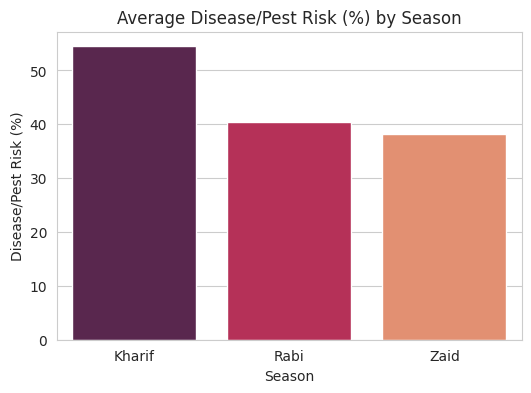

In [22]:
season_disease = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(['Kharif','Rabi','Zaid'])
print(season_disease)

plt.figure(figsize=(6,4))
sns.barplot(x=season_disease.index, y=season_disease.values, palette='rocket')
plt.title('Average Disease/Pest Risk (%) by Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.show()

**Disease/pest risk is highest in Kharif (54.5%)** — the humid, rainy monsoon season creates favorable conditions for pests and disease, compared to Rabi (40.5%) and Zaid (38.2%).

## 11. What Factors Are Most Correlated With Yield and Profit?

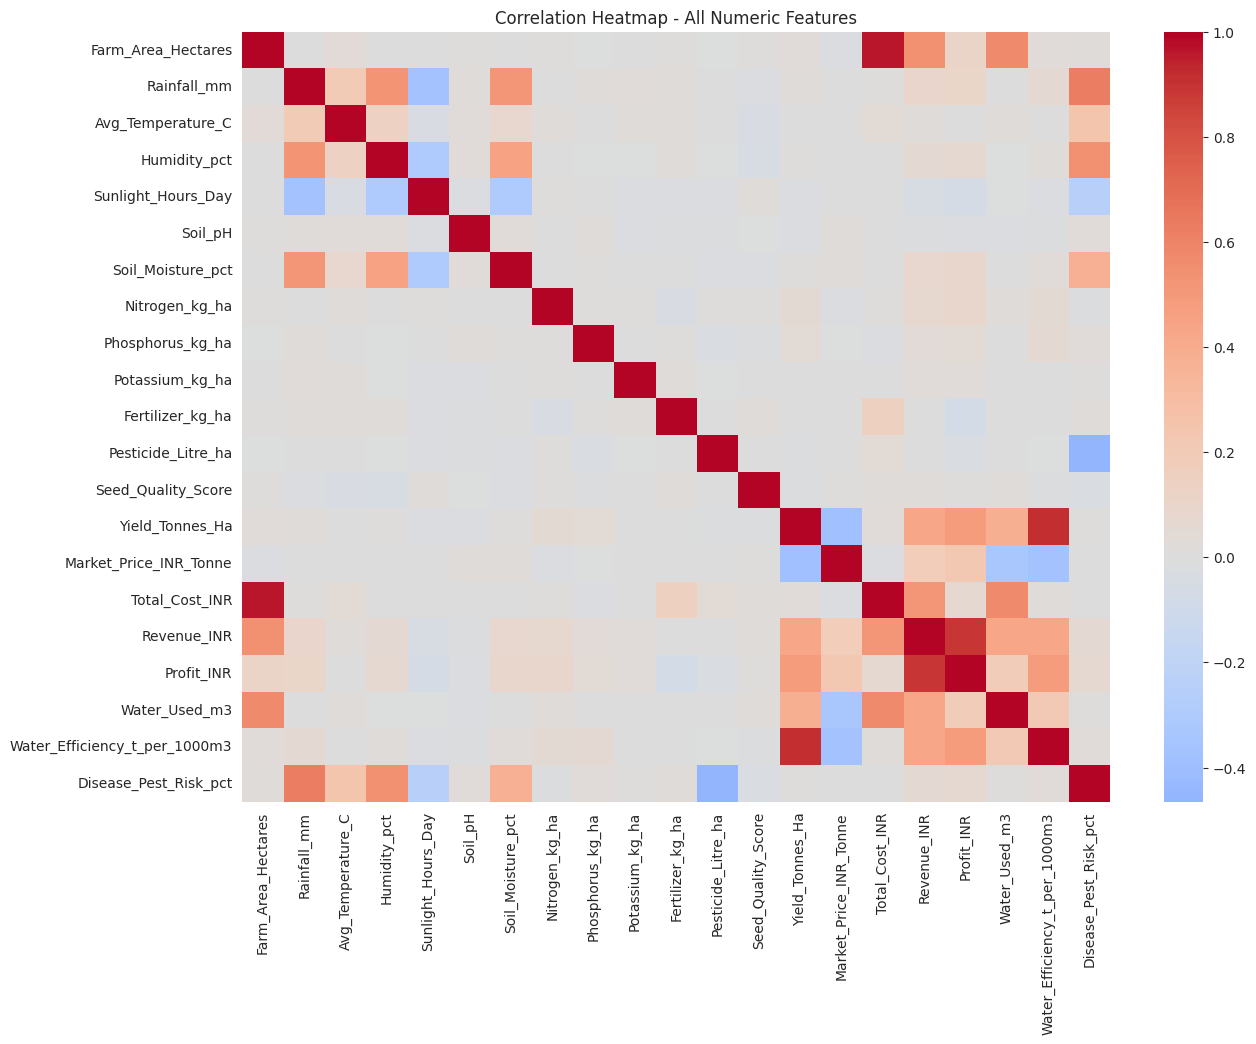

Top correlations with Yield_Tonnes_Ha:
 Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915517
Profit_INR                       0.489350
Revenue_INR                      0.433033
Water_Used_m3                    0.387373
Nitrogen_kg_ha                   0.053633
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
 Profit_INR                       1.000000
Revenue_INR                      0.887331
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489350
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Name: Profit_INR, dtype: float64


In [23]:
num_cols = ['Farm_Area_Hectares','Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
            'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Yield_Tonnes_Ha',
            'Market_Price_INR_Tonne','Total_Cost_INR','Revenue_INR','Profit_INR',
            'Water_Used_m3','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap - All Numeric Features')
plt.show()

print("Top correlations with Yield_Tonnes_Ha:\n", corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False).head(6))
print("\nTop correlations with Profit_INR:\n", corr_matrix['Profit_INR'].sort_values(ascending=False).head(6))

- **Water Efficiency is by far the strongest driver of Yield** (correlation 0.92) — far more than fertilizer, rainfall, or soil conditions.
- **Revenue is the strongest driver of Profit** (0.89), followed by Production and Yield.
- Interestingly, **Market Price is negatively correlated with Yield (-0.38)** — higher-yielding crops tend to sell at lower per-tonne prices (likely staple grains vs. high-value crops), an important nuance for profitability planning.
- Traditional inputs like Nitrogen, Phosphorus, Fertilizer and Soil pH show **very weak correlation with Yield** in this dataset — suggesting water management matters far more than nutrient dosage here.

## Yield vs. Water Efficiency (Scatter Plot)

Section 11 found Water Efficiency has the strongest correlation with Yield (0.92). A scatter plot lets us visually confirm this relationship and check whether it holds consistently across all three seasons, rather than trusting a single correlation number.

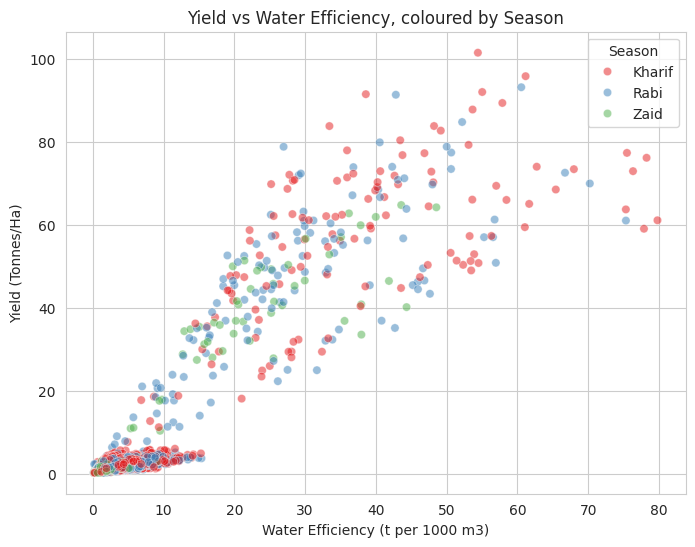

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Water_Efficiency_t_per_1000m3', y='Yield_Tonnes_Ha', hue='Season',
                 data=df, alpha=0.5, palette='Set1', hue_order=['Kharif','Rabi','Zaid'])
plt.title('Yield vs Water Efficiency, coloured by Season')
plt.xlabel('Water Efficiency (t per 1000 m3)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

**Insight:** The strong positive relationship is clearly visible and, importantly, **holds consistently across all three seasons** — the Kharif, Rabi and Zaid points all follow the same upward trend line rather than forming separate clusters. This confirms that water efficiency drives yield **regardless of season**, so improving irrigation efficiency (Section 13) should raise yield in any season, not just one.

## Multivariate Relationships (Pair Plot)

To see several key relationships at once rather than one pair at a time, this pair plot combines Yield, Profit, Water Efficiency and Disease/Pest Risk, coloured by Season. A full pair plot across all 20+ numeric columns would be too cluttered to read, so this focuses only on the variables that mattered most in the analysis above.

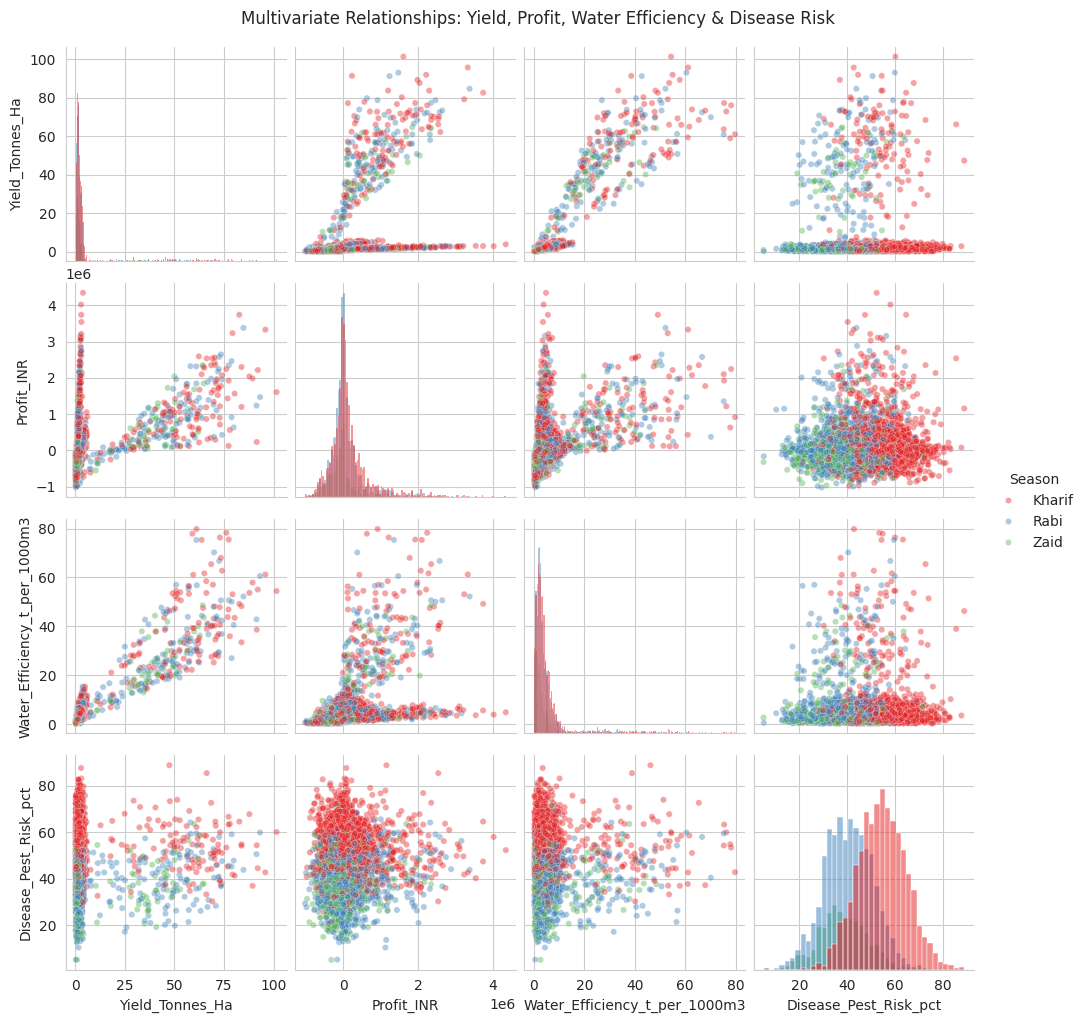

In [25]:
pair_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Season']
sns.pairplot(df[pair_cols], hue='Season', hue_order=['Kharif','Rabi','Zaid'], palette='Set1',
             plot_kws={'alpha':0.4, 's':20}, diag_kind='hist')
plt.suptitle('Multivariate Relationships: Yield, Profit, Water Efficiency & Disease Risk', y=1.02)
plt.show()

**Insight:** The pair plot confirms the Yield-Water Efficiency relationship visually once more, and shows that **Disease/Pest Risk has no clear linear relationship with Yield or Profit** in any season (the scatter is diffuse/random) — consistent with its very weak correlation values in Section 11. The diagonal histograms also reaffirm that Kharif (blue) skews toward higher water efficiency and yield than Zaid (green), matching the season-wise bar charts from Sections 6 and 9.

## 12. Crop-wise Profitability Across Seasons
### (Student-Designed Analysis 1)
I chose to investigate this because the earlier season-level profit comparison didn't explain *why* Zaid was loss-making — I wanted to check whether it was driven by specific crops rather than the season itself.

Season        Kharif      Rabi      Zaid
Crop                                    
Chilli      954380.0  638572.0  448659.0
Cotton      217000.0  107344.0  -53925.0
Groundnut   108265.0   10417.0  -68872.0
Maize       -39333.0  -89133.0 -194049.0
Pulses       43339.0  -14309.0 -139228.0
Rice        -64903.0  -98428.0 -227239.0
Sugarcane  1000791.0  731613.0  583636.0
Wheat      -105872.0 -119955.0 -193209.0


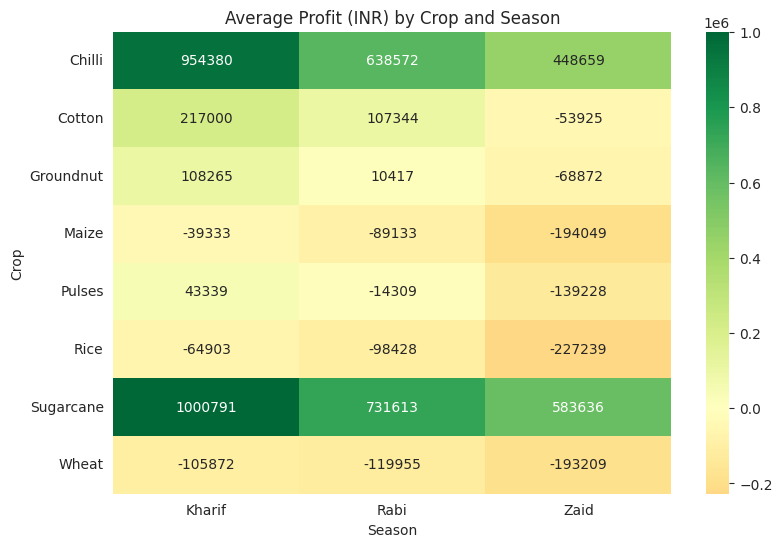

In [26]:
crop_season_profit = df.groupby(['Crop','Season'])['Profit_INR'].mean().unstack().reindex(columns=['Kharif','Rabi','Zaid'])
print(crop_season_profit.round(0))

plt.figure(figsize=(9,6))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by Crop and Season')
plt.show()

This heatmap reveals a **major, consistent pattern**:

- **Sugarcane and Chilli are highly profitable in every single season** — these are the standout crops overall.
- **Wheat, Rice, and Maize run at a loss in almost every season** — these staple grain crops consistently lose money across Kharif, Rabi and Zaid alike.
- **Cotton and Groundnut are profitable in Kharif/Rabi but turn negative in Zaid.**
- This suggests crop choice matters more than season for profitability in several cases — a farm growing Wheat will likely lose money regardless of season, while a farm growing Sugarcane will likely profit regardless of season.

## 13. Irrigation Method Effectiveness Across Seasons
### (Student-Designed Analysis 2)
Since Water Efficiency turned out to be the strongest driver of Yield (Section 11), I designed this analysis to check which irrigation method actually delivers that efficiency, and whether the best method changes by season.

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             6.80   3.64     8.85       4.62
Rabi               6.05   3.48     6.87       4.64
Zaid               5.30   2.73     5.48       4.86


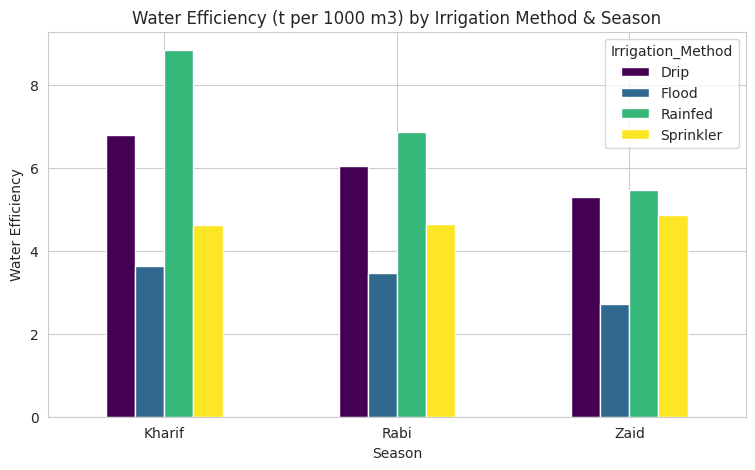

In [27]:
irrigation_season = df.groupby(['Season','Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].mean().unstack().reindex(['Kharif','Rabi','Zaid'])
print(irrigation_season.round(2))

irrigation_season.plot(kind='bar', figsize=(9,5), colormap='viridis')
plt.title('Water Efficiency (t per 1000 m3) by Irrigation Method & Season')
plt.ylabel('Water Efficiency')
plt.xticks(rotation=0)
plt.show()

**Rainfed and Drip irrigation consistently give the best water efficiency across all seasons**, while **Flood irrigation is the least efficient in every season** — flood irrigation wastes the most water relative to yield produced, regardless of season.

## 14. State-wise Yield Comparison

State
Punjab            6.121116
Karnataka         5.776554
Gujarat           5.752100
Telangana         5.048953
Maharashtra       5.017188
Madhya Pradesh    4.990875
Tamil Nadu        4.872907
Andhra Pradesh    4.628752
Name: Yield_Tonnes_Ha, dtype: float64


/tmp/ipykernel_1433/2713332293.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_yield.values, y=state_yield.index, palette='crest')


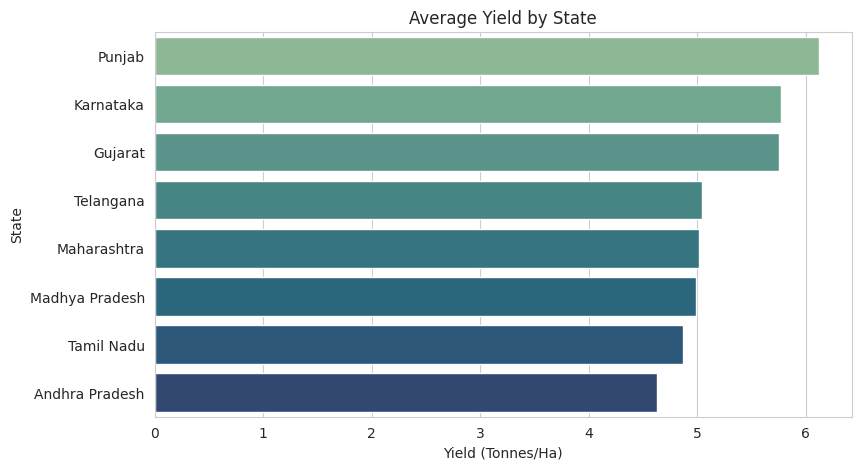

In [28]:
state_yield = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
print(state_yield)

plt.figure(figsize=(9,5))
sns.barplot(x=state_yield.values, y=state_yield.index, palette='crest')
plt.title('Average Yield by State')
plt.xlabel('Yield (Tonnes/Ha)')
plt.show()

**Punjab has the highest average yield (6.12 t/ha)**, followed by Karnataka and Gujarat, while **Andhra Pradesh has the lowest (4.65 t/ha)** — a difference of nearly 1.5 t/ha between the best and worst performing states.

## 15. Are Seasonal Patterns Consistent Across States?
### (Student-Designed Analysis 3)
The key-questions brief specifically asks whether seasonal patterns hold across regions, so I designed this state x season breakdown to test whether the Kharif > Rabi > Zaid yield ordering (Section 6) is universal or state-dependent.

Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.68  3.47  4.44
Gujarat           6.34  5.67  4.07
Karnataka         6.46  4.78  6.62
Madhya Pradesh    5.99  3.76  5.46
Maharashtra       5.43  5.50  2.27
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.50  4.10
Telangana         5.55  4.80  4.24


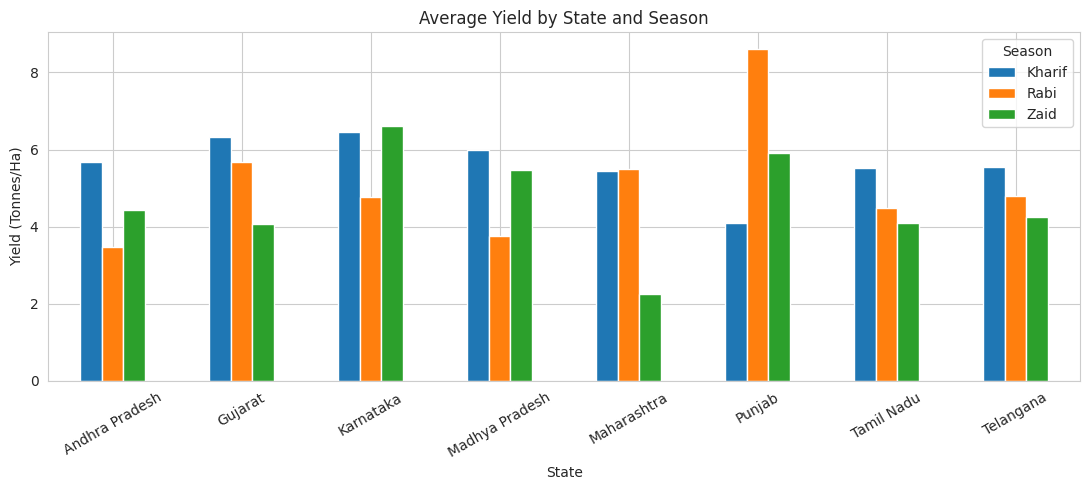

In [29]:
state_season_yield = df.groupby(['State','Season'])['Yield_Tonnes_Ha'].mean().unstack().reindex(columns=['Kharif','Rabi','Zaid'])
print(state_season_yield.round(2))

state_season_yield.plot(kind='bar', figsize=(11,5))
plt.title('Average Yield by State and Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=30)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

The Kharif > Rabi > Zaid yield ordering **does not hold uniformly across all states** — some states (e.g. Gujarat, Tamil Nadu) show a much smaller Kharif-Zaid gap than others, indicating that regional factors moderate the seasonal effect rather than season acting the same way everywhere.

## 16. Unusual / Unexpected Patterns

- **Zaid season is loss-making on average, despite reasonable yields** — this is unexpected because yield differences across seasons were small (and not statistically significant), yet profit differences are large and highly significant. This points to **Zaid crops fetching lower prices or facing higher costs**, not lower productivity.
- **Higher-yielding crops fetch lower market prices** (negative correlation -0.38) — counterintuitive, since one might expect better yields to mean better outcomes, but staple grains (Wheat, Rice) which often yield reasonably well are systematically loss-making due to low per-tonne prices relative to cost.
- **Traditional agronomic inputs (Nitrogen, Phosphorus, Potassium, Fertilizer, Soil pH) show almost no correlation with Yield**, while **Water Efficiency dominates** — suggesting water management is the single most important lever for improving yield in this dataset.

## 17. Key Questions — Summary of Findings

| Question | Finding |
|---|---|
| How does performance vary across seasons? | Yield varies mildly (not statistically significant); Profit varies sharply and significantly (Kharif best, Zaid loss-making) |
| Major seasonal patterns? | Kharif = high rainfall & high disease risk; Rabi = mild temperature; Zaid = high temperature & lowest water efficiency |
| Which characteristics change most? | Rainfall, Temperature, Water Efficiency, and Profit change the most between seasons |
| Resource usage variation? | Water efficiency drops from Kharif -> Rabi -> Zaid; Flood irrigation is least efficient in every season |
| Environment-performance relationship? | Water Efficiency (not rainfall or fertilizer) is the strongest driver of Yield |
| Economic outcome variation? | Kharif most profitable, Zaid loss-making on average |
| Consistent across regions? | Partially — yield ordering across seasons differs by state |
| Unusual patterns? | Zaid's loss despite similar yield; high-yield crops fetching lower prices; weak fertilizer-yield link |
| Actionable insight? | Crop choice (Sugarcane/Chilli vs. Wheat/Rice/Maize) drives profitability more consistently than season alone |

## 18. Conclusions & Recommendations

**Conclusions:**
1. Season has a **significant effect on profitability but not on yield** — the Zaid (summer) season is loss-making on average despite comparable yields, implying price/cost dynamics rather than productivity are the real seasonal risk.
2. **Water efficiency, not fertilizer or rainfall, is the dominant driver of yield** in this dataset.
3. **Crop selection matters more than season** for consistent profitability — Sugarcane and Chilli are reliably profitable, while Wheat, Rice and Maize are reliably loss-making across all seasons.
4. **Flood irrigation is the least water-efficient method in every season**, while Drip and Rainfed perform best.
5. Regional (state-level) factors moderate seasonal effects — the same season does not perform identically everywhere.

**Recommendations:**
- Farmers cultivating in the **Zaid season** should reconsider crop choice or seek better price realization/contracts, since yield alone won't fix the loss-making pattern.
- Encourage **wider adoption of Drip/Rainfed irrigation over Flood irrigation**, especially in Zaid, to improve water efficiency.
- Government/agri-extension programs could prioritize **crop diversification support** (e.g. incentivizing Sugarcane/Chilli-style high-value crops) in regions currently dependent on consistently loss-making staple crops.
- Further investigation is recommended into **why high-yield crops fetch lower market prices**, as this directly undermines the profitability of otherwise productive farms.

## Limitations

- **Imputed values:** Missing `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` values (about 1-1.2% of records each) were filled using season+crop medians. This is a reasonable approximation but slightly understates the true variability in those columns.
- **Cross-sectional data:** The dataset captures a snapshot across seasons but not the *same* farms tracked over multiple years, so we can observe seasonal association but cannot claim causation (e.g. we can't confirm season *causes* the profit difference vs. other correlated factors specific to when/where Zaid crops were grown).
- **No price/cost breakdown:** `Total_Cost_INR` is available only as a single aggregate figure, so we could not separate which cost component (labor, seeds, irrigation infrastructure, etc.) drives the Zaid-season losses.
- **Outliers retained:** High-profit outliers (Sugarcane/Chilli) were deliberately kept rather than removed, which is appropriate for this analysis but means summary averages (means) are pulled upward by a minority of high-value crops.
- **Geographic scope:** Only 8 Indian states are represented, so findings may not generalize to regions or farming systems outside this sample.

## Final Conclusion

This analysis set out to answer one central question: **how does agricultural performance change across seasons, and what patterns explain those changes?**

The evidence shows that **season affects profitability far more than it affects yield**. Kharif, Rabi and Zaid produce statistically similar yields, yet Zaid is loss-making on average while Kharif is the most profitable season — a gap driven by economics (crop choice, pricing) rather than farm productivity. The single strongest technical lever for improving yield across all seasons is **water-use efficiency**, not fertilizer or soil inputs, and **Drip/Rainfed irrigation consistently outperforms Flood irrigation** in delivering that efficiency. At the same time, **crop selection is the most powerful lever for profitability** — Sugarcane and Chilli remain profitable in every season studied, while Wheat, Rice and Maize are consistently loss-making regardless of season.

Taken together, these findings suggest that seasonal agricultural planning should focus less on "which season is better" in isolation, and more on **matching the right crop and irrigation method to each season** — since the data shows performance is really shaped by that combination, not by season alone.